In [19]:
import zipfile
import pandas as pd
import numpy as np
import os

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

paths = ["../data/BALBc_no1.zip",
        "../data/BALBc_no2.zip",
        "../data/BALBc_no3.zip"]

all_data : dict[list[pd.DataFrame]] = {}

for path in paths:

    dataFrames : list[pd.DataFrame] = []

    with zipfile.ZipFile(path) as z:
        print("File list: ", z.namelist())

        for name in z.namelist():
            if name.endswith(".csv"):

                with z.open(name) as f:
                    df = pd.read_csv(f, sep=";")

                dataFrames.append(df)
    
    all_data[z.namelist()[0].rstrip("/")] = dataFrames
    print(f"Added {path}...")


File list:  ['BALBc_no1/', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_edges_processed.csv', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_nodes_processed.csv', 'BALBc_no1/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no1_iso3um_stitched_segmentation_bulge_size_3.0_atlas_processed.csv']
Added ../data/BALBc_no1.zip...
File list:  ['BALBc_no2/', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0_edges_processed.csv', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0_nodes_processed.csv', 'BALBc_no2/BALBc-no2_iso3um_stitched_segmentation_bulge_size_3.0/BALBc-no2

In [4]:
print("All raw data size: ", len(all_data))
for i in all_data:
    print(i, "size:", len(all_data[i]))

All raw data size:  3
BALBc_no1 size: 3
BALBc_no2 size: 3
BALBc_no3 size: 3


In [5]:
for i in all_data:
    print(f"========={i} ==========")
    for j in all_data[i]:
        print("------dataFrame------")
        print(j.info(), "\n")

=========BALBc_no1 ==========
------dataFrame------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5345897 entries, 0 to 5345896
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   node1id                int64  
 2   node2id                int64  
 3   length                 float64
 4   distance               float64
 5   curveness              float64
 6   volume                 int64  
 7   avgCrossSection        float64
 8   minRadiusAvg           float64
 9   minRadiusStd           float64
 10  avgRadiusAvg           float64
 11  avgRadiusStd           float64
 12  maxRadiusAvg           float64
 13  maxRadiusStd           float64
 14  roundnessAvg           float64
 15  roundnessStd           float64
 16  node1_degree           int64  
 17  node2_degree           int64  
 18  num_voxels             int64  
 19  hasNodeAtSampleBorder  int64  
dtypes: float64(12), int64(8)
memory usage:

In [6]:
for i in all_data:
    print(f"========={i} ==========")
    for j in all_data[i]:
        print("------dataFrame------")
        print(j.head(15), "\n")

=========BALBc_no1 ==========
------dataFrame------
    id  node1id  node2id     length   distance  curveness  volume  \
0    0        0   278560  182.46400  167.94600    1.08644    9164   
1    1        1        3    9.98625    6.70820    1.48866      97   
2    2        2   249900    2.48805    2.44949    1.01574     134   
3    3        4   249907   24.57610   20.87260    1.17743    1201   
4    4        5   249901    3.66110    3.60555    1.01541     330   
5    5        6   249900   25.39440   19.31320    1.31487    1113   
6    6        7   249920   41.01840   38.37320    1.06894    2857   
7    7        8   249902    6.00833    5.61249    1.07053     300   
8    8        9   249948   13.90060   13.63820    1.01924      56   
9    9       10   249947   17.44840   10.24700    1.70279     111   
10  10       11   249949   87.94370   85.18410    1.03240     894   
11  11       12   249944   57.76390   54.75400    1.05497     736   
12  12       13   249999   19.65050   12.68860    1

In [11]:
BALBc_1_1 : pd.DataFrame = all_data["BALBc_no1"][0]
BALBc_1_2 : pd.DataFrame = all_data["BALBc_no1"][1]
BALBc_1_3 : pd.DataFrame = all_data["BALBc_no1"][2]
BALBc_2_1 : pd.DataFrame = all_data["BALBc_no2"][0]
BALBc_2_2 : pd.DataFrame = all_data["BALBc_no2"][1]
BALBc_2_3 : pd.DataFrame = all_data["BALBc_no2"][2]
BALBc_3_1 : pd.DataFrame = all_data["BALBc_no3"][0]
BALBc_3_2 : pd.DataFrame = all_data["BALBc_no3"][1]
BALBc_3_3 : pd.DataFrame = all_data["BALBc_no3"][2]

print("BALBc_1:", BALBc_1_1.columns)
print("BALBc_1:", BALBc_1_2.columns)
print("BALBc_1:", BALBc_1_3.columns)
print("BALBc_2:", BALBc_2_1.columns)
print("BALBc_2:", BALBc_2_2.columns)
print("BALBc_2:", BALBc_2_3.columns)
print("BALBc_3:", BALBc_3_1.columns)
print("BALBc_3:", BALBc_3_2.columns)
print("BALBc_3:", BALBc_3_3.columns)

BALBc_1: Index(['id', 'node1id', 'node2id', 'length', 'distance', 'curveness', 'volume',
       'avgCrossSection', 'minRadiusAvg', 'minRadiusStd', 'avgRadiusAvg',
       'avgRadiusStd', 'maxRadiusAvg', 'maxRadiusStd', 'roundnessAvg',
       'roundnessStd', 'node1_degree', 'node2_degree', 'num_voxels',
       'hasNodeAtSampleBorder'],
      dtype='object')
BALBc_1: Index(['id', 'pos_x', 'pos_y', 'pos_z', 'degree', 'isAtSampleBorder'], dtype='object')
BALBc_1: Index(['Region_Acronym_ACA', 'Region_Acronym_AI', 'Region_Acronym_AOB',
       'Region_Acronym_AOBgr', 'Region_Acronym_AON', 'Region_Acronym_AUD',
       'Region_Acronym_BLA', 'Region_Acronym_BMA', 'Region_Acronym_BS',
       'Region_Acronym_CA1sp', 'Region_Acronym_CB', 'Region_Acronym_CBXmo',
       'Region_Acronym_CNU', 'Region_Acronym_COA', 'Region_Acronym_CTXsp',
       'Region_Acronym_CUL4', 'Region_Acronym_DORpm', 'Region_Acronym_DORsm',
       'Region_Acronym_DP', 'Region_Acronym_ECT', 'Region_Acronym_EP',
       'Region_Acr

## **BALBc 1**

### 1. Describe

In [18]:
BALBc_1_1.describe()

,id,node1id,node2id,length,distance,curveness,volume,avgCrossSection,minRadiusAvg,minRadiusStd,avgRadiusAvg,avgRadiusStd,maxRadiusAvg,maxRadiusStd,roundnessAvg,roundnessStd,node1_degree,node2_degree,num_voxels,hasNodeAtSampleBorder
count,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06,5.345897e+06
mean,2.672948e+06,1.806530e+06,1.896018e+06,1.279869e+01,1.145000e+01,1.088693e+00,3.899617e+02,2.824333e+01,2.476473e+00,3.649567e-01,3.508176e+00,4.196538e-01,4.739847e+00,7.138724e-01,5.314004e-01,9.184909e-02,3.133139e+00,3.268482e+00,8.902883e+00,1.496475e-06
std,1.543228e+06,9.993347e+05,9.488214e+05,9.064357e+00,7.218522e+00,1.636323e-01,5.647224e+02,2.050822e+01,1.121808e+00,3.353218e-01,1.217720e+00,3.752447e-01,1.600603e+00,6.338605e-01,1.203201e-01,8.568570e-02,7.247576e-01,5.962765e-01,7.725755e+00,1.223304e-03
min,0.000000e+00,0.000000e+00,3.000000e+00,2.000000e+00,1.776800e+00,1.862633e-01,1.000000e+00,2.981420e-01,5.000000e-01,0.000000e+00,7.947460e-01,0.000000e+00,9.174240e-01,0.000000e+00,4.718740e-02,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,1.336474e+06,9.458470e+05,1.074399e+06,6.686590e+00,6.442050e+00,1.018540e+00,1.340000e+02,1.668850e+01,1.788670e+00,1.853900e-01,2.762130e+00,1.935620e-01,3.750970e+00,3.233260e-01,4.569560e-01,5.393870e-02,3.000000e+00,3.000000e+00,4.000000e+00,0.000000e+00
50%,2.672948e+06,1.806942e+06,1.895007e+06,1.039630e+01,9.780900e+00,1.042930e+00,2.550000e+02,2.404800e+01,2.322540e+00,3.146660e-01,3.358020e+00,3.405610e-01,4.494290e+00,5.631100e-01,5.333080e-01,8.372510e-02,3.000000e+00,3.000000e+00,7.000000e+00,0.000000e+00
75%,4.009422e+06,2.669647e+06,2.717500e+06,1.606630e+01,1.444540e+01,1.093960e+00,4.660000e+02,3.408110e+01,2.926540e+00,4.637680e-01,4.015180e+00,5.482020e-01,5.381560e+00,9.289000e-01,6.039490e-01,1.166110e-01,3.000000e+00,3.000000e+00,1.200000e+01,0.000000e+00
max,5.345896e+06,3.538492e+06,3.538494e+06,3.228130e+02,3.006980e+02,2.743440e+01,1.194590e+05,1.587499e+03,3.865820e+01,1.249650e+01,3.865820e+01,1.199950e+01,4.412900e+01,2.364330e+01,1.997629e+00,1.000000e+00,1.400000e+01,1.400000e+01,2.560000e+02,1.000000e+00


In [16]:
BALBc_1_2.describe()

,id,pos_x,pos_y,pos_z,degree,isAtSampleBorder
count,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06
mean,1.769247e+06,1.563105e+03,2.915366e+03,9.119264e+02,3.021565e+00,2.543454e-06
std,1.021476e+06,6.370472e+02,8.961347e+02,4.022904e+02,7.359357e-01,1.594819e-03
min,0.000000e+00,1.780000e+02,8.080000e+02,0.000000e+00,1.000000e+00,0.000000e+00
25%,8.846235e+05,1.054500e+03,2.201330e+03,5.870000e+02,3.000000e+00,0.000000e+00
50%,1.769247e+06,1.548670e+03,2.905000e+03,9.141670e+02,3.000000e+00,0.000000e+00
75%,2.653870e+06,2.059500e+03,3.692000e+03,1.224000e+03,3.000000e+00,0.000000e+00
max,3.538494e+06,3.096000e+03,4.719000e+03,1.866330e+03,1.400000e+01,1.000000e+00


In [17]:
BALBc_1_3.describe()

,Region_Acronym_ACA,Region_Acronym_AI,Region_Acronym_AOB,Region_Acronym_AOBgr,Region_Acronym_AON,Region_Acronym_AUD,Region_Acronym_BLA,Region_Acronym_BMA,Region_Acronym_BS,Region_Acronym_CA1sp,...,Region_Acronym_TEa,Region_Acronym_TR,Region_Acronym_TT,Region_Acronym_VIS,Region_Acronym_VISC,Region_Acronym_VS,Region_Acronym_bgr,Region_Acronym_fiber tracts,Region_Acronym_root,Region_Acronym_sAMY
count,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,...,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06,3.538495e+06
mean,1.072179e-02,1.464295e-02,8.396225e-04,9.447519e-04,9.210413e-03,1.502447e-02,2.648584e-03,2.122371e-03,1.475769e-03,1.674158e-03,...,5.892901e-03,1.876221e-03,2.538367e-03,2.778526e-02,3.693943e-03,7.905903e-03,7.879141e-02,4.937042e-02,4.598565e-03,6.167876e-03
std,1.029895e-01,1.201188e-01,2.896408e-02,3.072230e-02,9.552792e-02,1.216501e-01,5.139620e-02,4.602029e-02,3.838738e-02,4.088222e-02,...,7.653872e-02,4.327472e-02,5.031823e-02,1.643571e-01,6.066547e-02,8.856299e-02,2.694130e-01,2.166403e-01,6.765663e-02,7.829327e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


### 2. EDA

In [49]:
# bỏ các cột id
df_plot = BALBc_1_1.drop(columns=["id", "node1id", "node2id", "hasNodeAtSampleBorder"])

# sampling để plot nhanh
df_sample = df_plot.sample(n=100000, random_state=42)

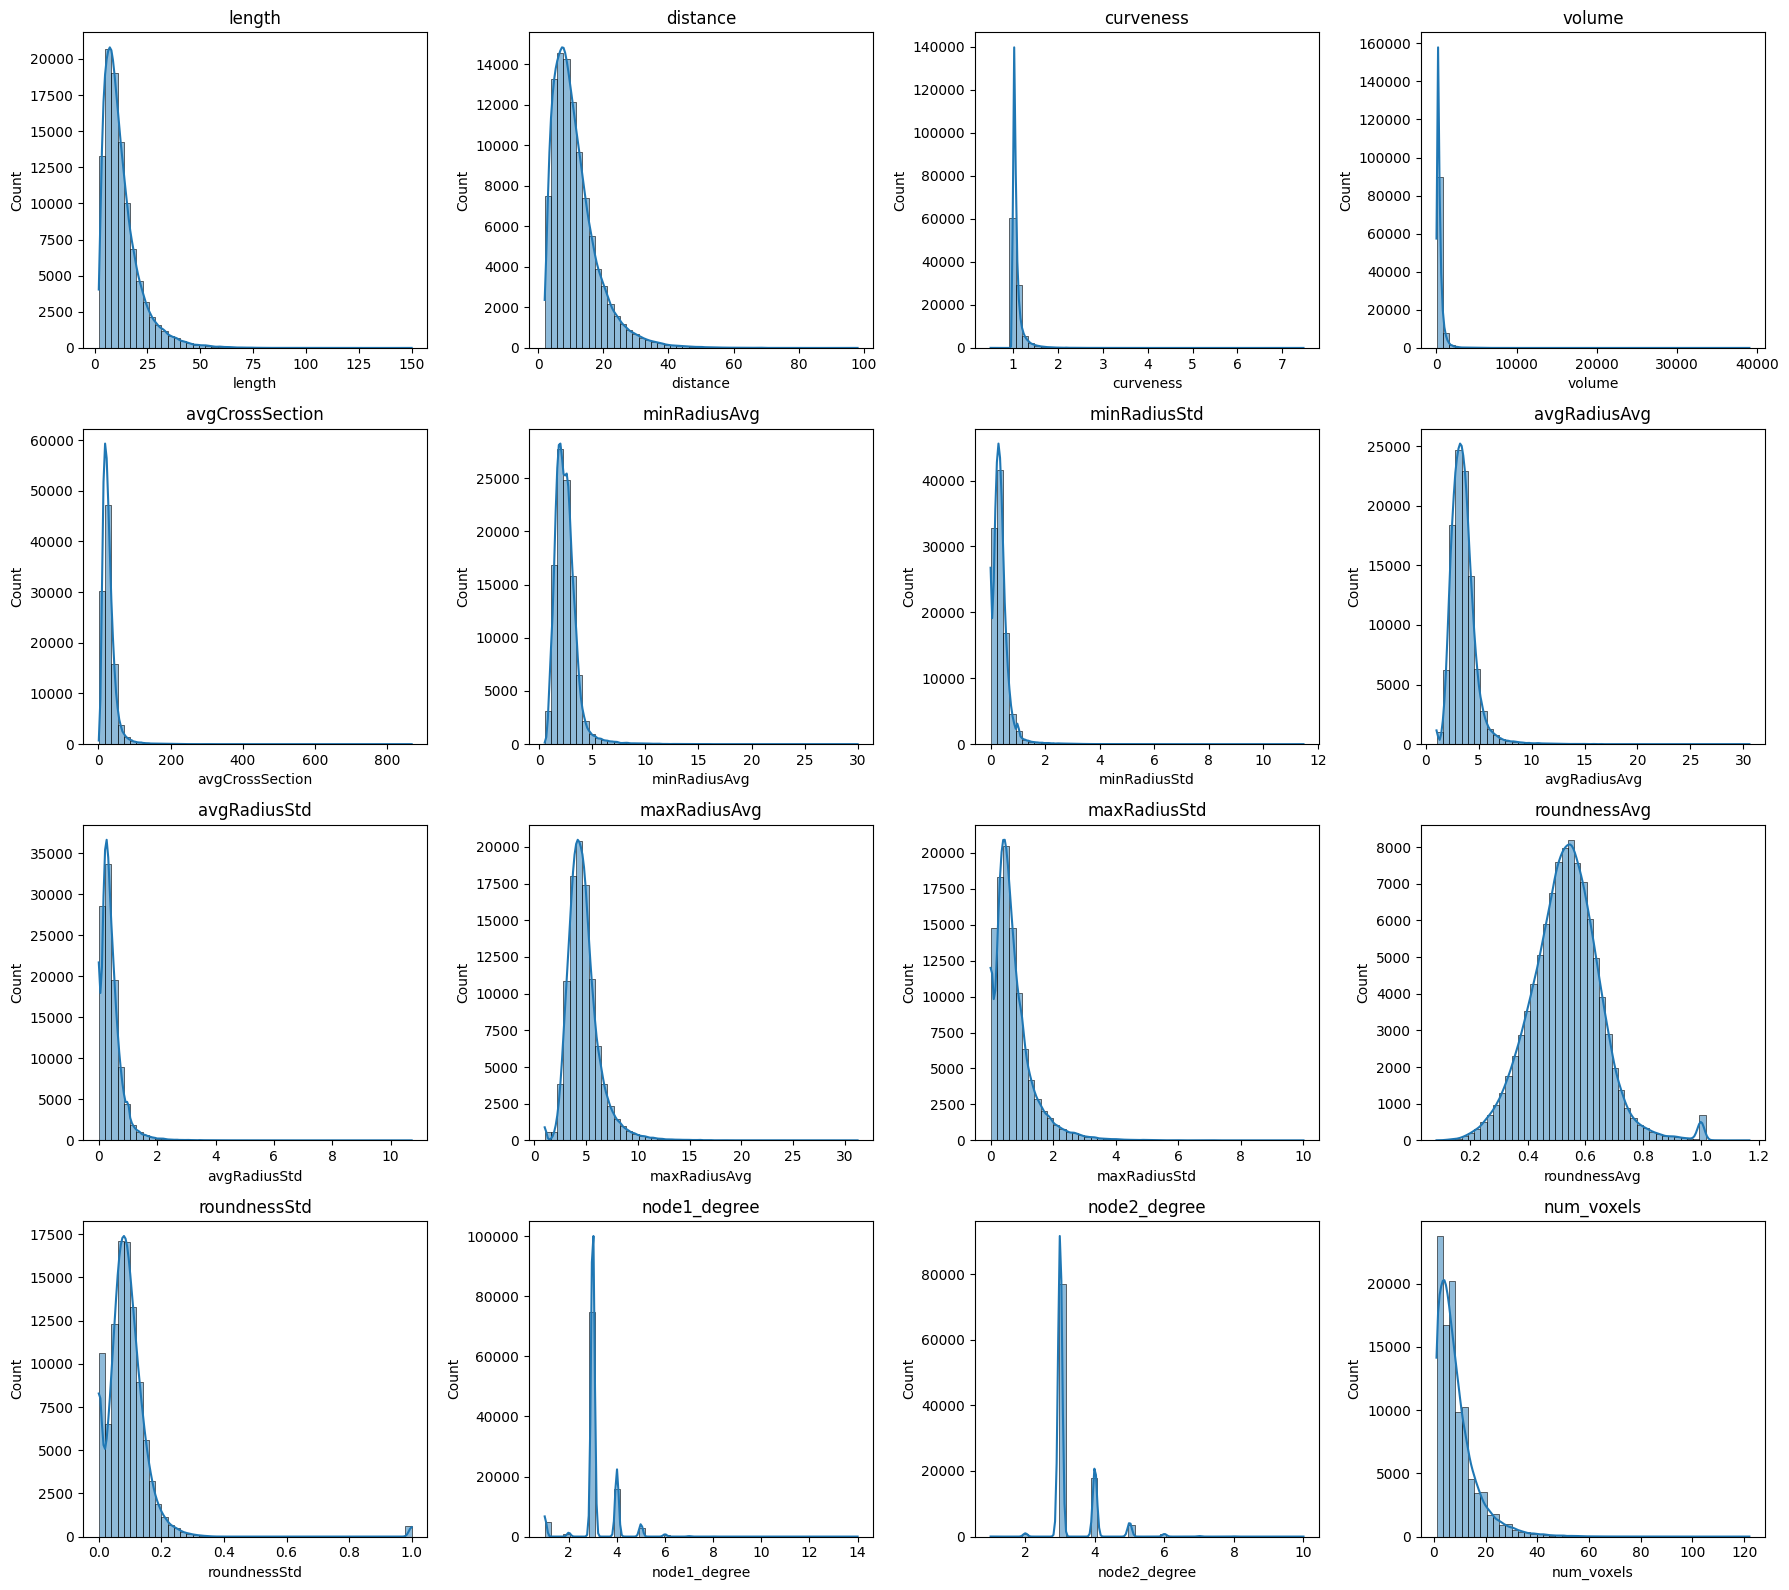

In [50]:
cols = df_sample.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sample[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

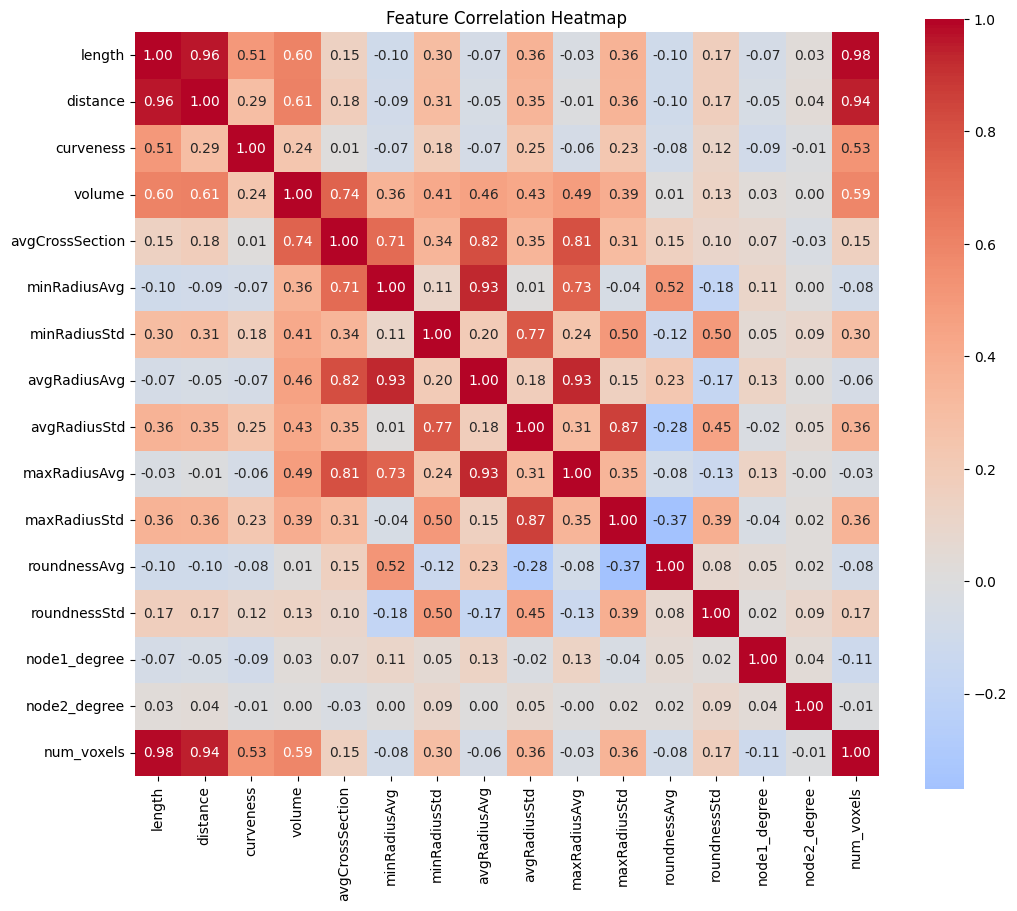

In [51]:
# tính correlation
corr = df_sample.corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    annot=True,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [30]:
# bỏ các cột id
df_plot = BALBc_1_2.drop(columns=["id", "pos_x", "pos_y", "pos_z"])

# sampling để plot nhanh
df_sample = df_plot.sample(n=100000, random_state=42)

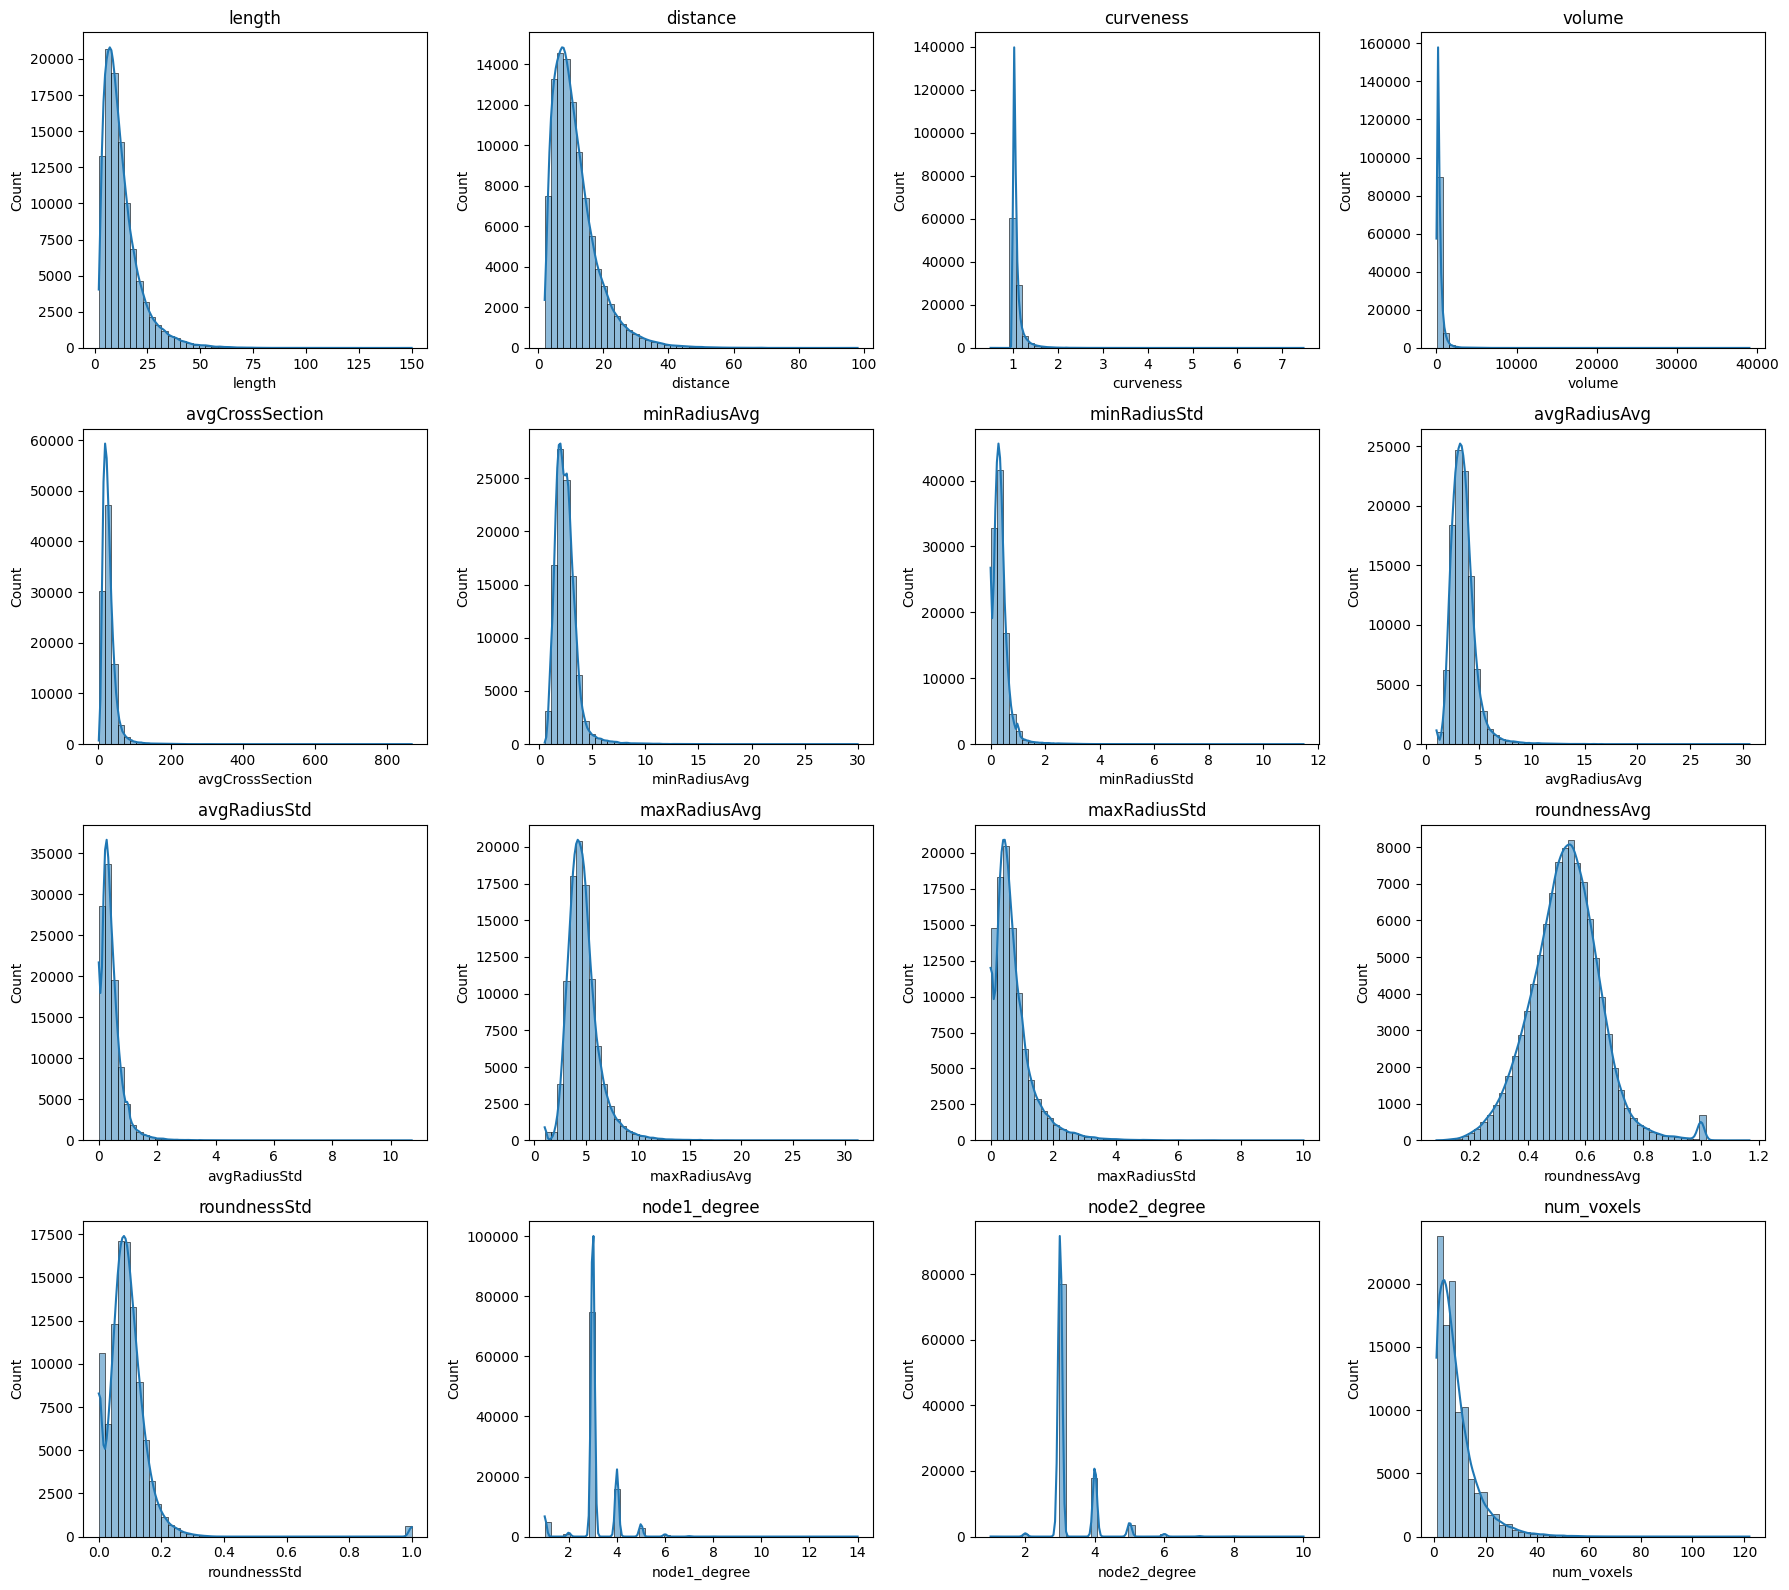

In [52]:
cols = df_sample.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sample[col], bins=50, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

### 3. Features

In [54]:
# bỏ các cột id
df_feats = BALBc_1_3

# sampling để plot nhanh
df_sam_feats = df_feats.sample(n=100000, random_state=42)

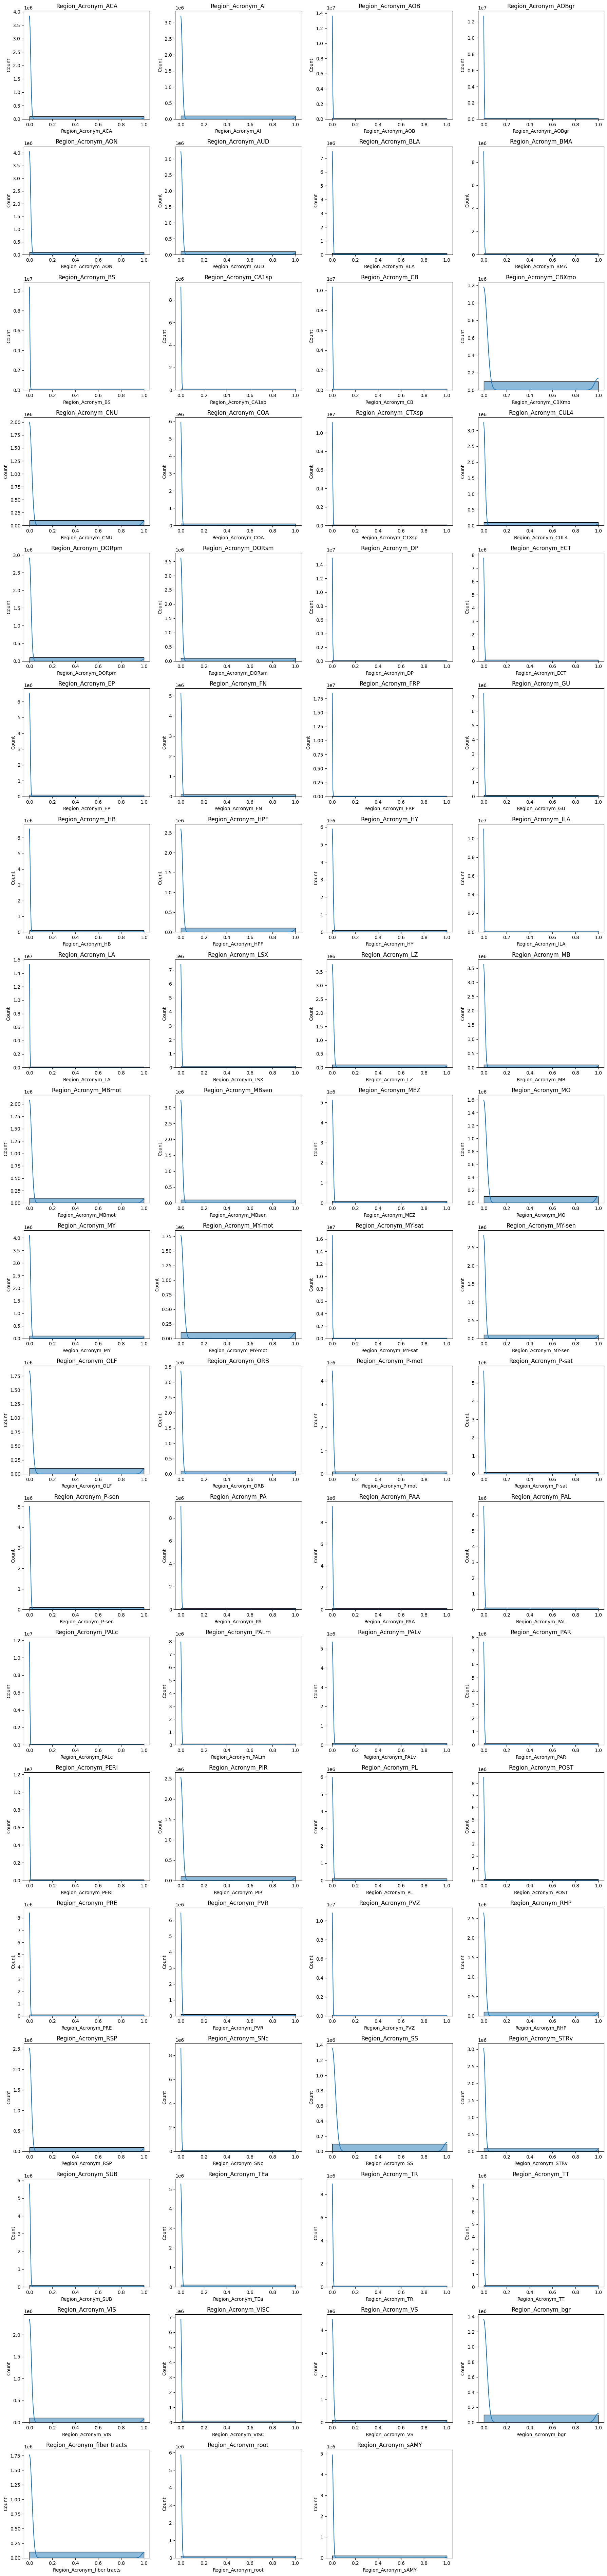

In [ ]:
cols = df_sam_feats.columns

n_cols = 4
n_rows = (len(cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4 * n_rows))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_sam_feats[col], bins=10, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()